In [5]:
# imports

import os
import re

import pandas as pd
import numpy as np


from matplotlib.lines import Line2D

import matplotlib.pyplot as plt


Processing file: ../custom_logs/1x24=24_devel_n23m0123_63194313.csv, slurm_id: 63194313
  --> Keeping file
Processing file: ../custom_logs/1x24=24_devel_r23m0124_63181934.csv, slurm_id: 63181934
  --> Keeping file
Processing file: ../custom_logs/2x96(x2)=96_c23g_n23g0024,n23m0150_63975441.csv, slurm_id: 63975441
  --> Filtering out file
Processing file: ../custom_logs/2x96(x2)=96_c23g_n23g0002,n23m0009_63305190.csv, slurm_id: 63305190
  --> Filtering out file
Processing file: ../custom_logs/2x96(x2)=96_c23g_n23g0005,n23m0231_63973326.csv, slurm_id: 63973326
  --> Filtering out file
Processing file: ../custom_logs/2x96(x2)=96_c23mm_n23g0003,n23m0091_63323971.csv, slurm_id: 63323971
  --> Filtering out file
Processing file: ../custom_logs/1x24=24_devel_n23m0123_63529857.csv, slurm_id: 63529857
  --> Keeping file
Processing file: ../custom_logs/1x24=24_devel_n23m0123_64996414.csv, slurm_id: 64996414
  --> Keeping file
Processing file: ../custom_logs/1x8=8_devel_n23m0123_63181523.csv, slur

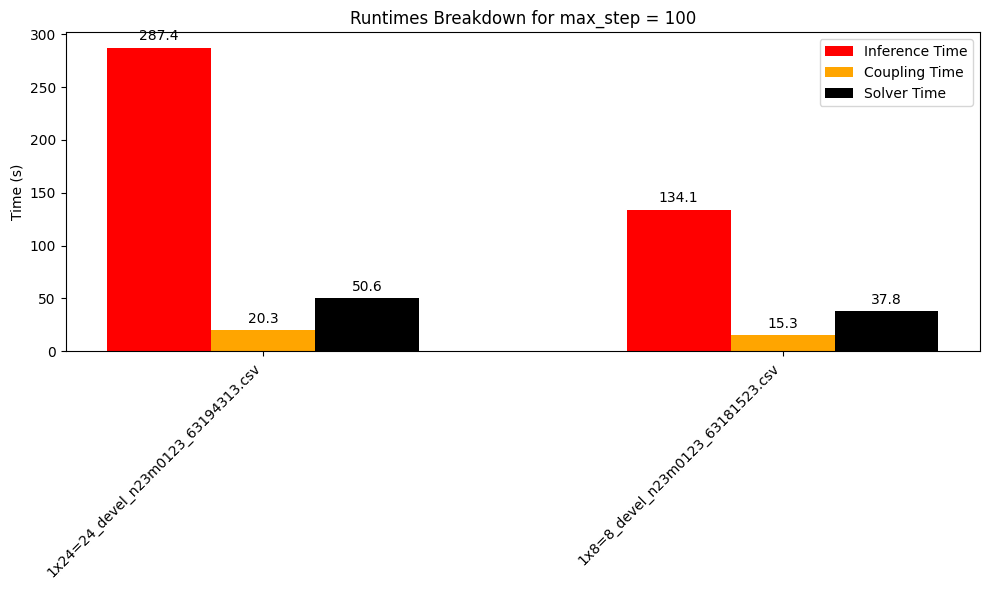

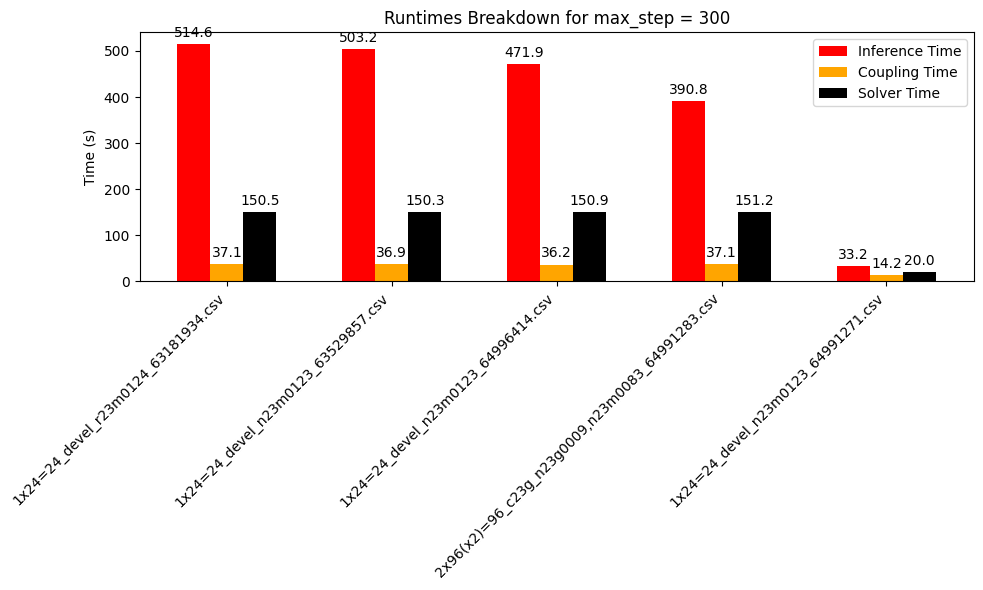

In [12]:
dfs = []
#paths = ['../custom_logs/0:8_devel_n23m0123_job_63143746.csv',
#         '../custom_logs/0:8_c23mm_n23m0290_job_63168238.csv',
#         '../custom_logs/0:16_c23mm_n23m[0163,0372]_job_63175247.csv']

paths = []
for file in os.listdir("../custom_logs/"):
    if file.endswith(".csv"):
        paths.append(os.path.join("../custom_logs/", file))

re.compile(r"_(\d+).csv")

filtered = 0

rm_paths = []

for path in paths:
    match = re.search(r"_(\d+).csv", path)
    slurm_id = int(match.group(1)) if match else -1
    # Keep files that have "devel" OR slurm_id >= 64000000
    print(f"Processing file: {path}, slurm_id: {slurm_id}")
    if "devel" in path or slurm_id >= 64000000:
        print("  --> Keeping file")
        devel = pd.read_csv(path)
        dfs.append(devel)
    else:
        print("  --> Filtering out file")
        filtered += 1
        rm_paths.append(path)
        
for rm_path in rm_paths:
    paths.remove(rm_path)
    
print("Filtered out {} files".format(filtered))


for i, df in enumerate(dfs):
    
    
    print(f"Processing file: {paths[i]}")

    # logical_time_step,global_time_step,restart_time_step,coupling,inference,count,clock

    # verify that timestamps are sorted in ascending order
    for j in range(1, len(df)):
        if df.loc[j, 'timestamp'] < df.loc[j-1, 'timestamp']:
            print(type(df.loc[j, 'timestamp']))
            print(f"decreasing timestamp at step {df.loc[j, 'global_time_step']} in file {paths[i]}")
            print(f"{df.loc[j-1, 'timestamp']} > {df.loc[j, 'timestamp']}, but the diff is {df.loc[j-1, 'global_time_step'] - df.loc[j, 'global_time_step']}")

    # add column for time differences to previous step, use 0 for first step, divide by 1e9 to convert from ns to s
    df['time_diff'] = df['timestamp'].diff().fillna(0) / 1e9
    df['clock'] = df['clock'].fillna(0) / 1e9
    df['clock_time_diff_diff'] = df['clock'] - df['time_diff']
    
    # move entries by one to back, fill last entry with 0
    df['time_diff'] = df['time_diff'].shift(-1).fillna(0)

    dfs[i] = df
    

# sort dfs by avg time per step, so that the plots are ordered by runtime
dfs = sorted(dfs, key=lambda df: df['time_diff'].mean(), reverse=True)

runtimes = pd.DataFrame(columns=['file', 'num_steps', 'max_step', 'total_time', 'avg_time_per_step', 'inference_time_total', 'coupling_time_total', 'solver_time_total'])

for i, df in enumerate(dfs):
    print(f"--- File: {paths[i]} ---")
    print(f"Number of steps: {len(df)}")
    print(f"Max global time step: {df['global_time_step'].max()-1}")
    total_time = ((df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]) / 1e9)
    print(f"Total time: {total_time:.2f} s")
    print(f"Average time per step: {df['time_diff'].mean():.2f} s  ({(df['time_diff'].mean() / total_time) * 100:.2f}%)")
    print(f"Inferece time total: {df[df['inference'] == 1]['time_diff'].sum():.2f} s  ({(df[df['inference'] == 1]['time_diff'].sum() / total_time) * 100:.2f}%)")
    print(f"Coupling time total: {df[(df['coupling'] == 1) & (df['inference'] == 0)]['time_diff'].sum():.2f} s  ({(df[(df['coupling'] == 1) & (df['inference'] == 0)]['time_diff'].sum() / total_time) * 100:.2f}%)")
    print(f"Solver time total:    {df[(df['inference'] == 0) & (df['coupling'] == 0)]['time_diff'].sum():.2f} s  ({(df[(df['inference'] == 0) & (df['coupling'] == 0)]['time_diff'].sum() / total_time) * 100:.2f}%)")
    print()
    
    # Let's plot this data, first we need to create a df for this
    runtimes.loc[i] = [os.path.basename(paths[i]),
                       len(df),
                       df['global_time_step'].max()-1,
                       total_time,
                       df['time_diff'].mean(),
                       df[df['inference'] == 1]['time_diff'].sum(),
                       df[(df['coupling'] == 1) & (df['inference'] == 0)]['time_diff'].sum(),
                       df[(df['inference'] == 0) & (df['coupling'] == 0)]['time_diff'].sum()]
    
runtimes.head()

# Let's plot the runtimes, but grouped by the max_step, so each different max_step has its own graph

for max_step in runtimes['max_step'].unique():
    subset = runtimes[runtimes['max_step'] == max_step]
    
    plt.figure(figsize=(10, 6))
    bar_width = 0.2
    bars1 = plt.bar(np.arange(len(subset)) - bar_width, subset['inference_time_total'], width=bar_width, label='Inference Time', color='red')
    bars2 = plt.bar(np.arange(len(subset)), subset['coupling_time_total'], width=bar_width, label='Coupling Time', color='orange')
    bars3 = plt.bar(np.arange(len(subset)) + bar_width, subset['solver_time_total'], width=bar_width, label='Solver Time', color='black')
    
    # Add value labels on top of each bar
    plt.bar_label(bars1, fmt='%.1f', padding=3)
    plt.bar_label(bars2, fmt='%.1f', padding=3)
    plt.bar_label(bars3, fmt='%.1f', padding=3)
    
    plt.xticks(np.arange(len(subset)), subset['file'], rotation=45, ha='right')
    plt.ylabel('Time (s)')
    plt.title(f'Runtimes Breakdown for max_step = {max_step}')
    plt.legend()
    plt.tight_layout()
    plt.show()



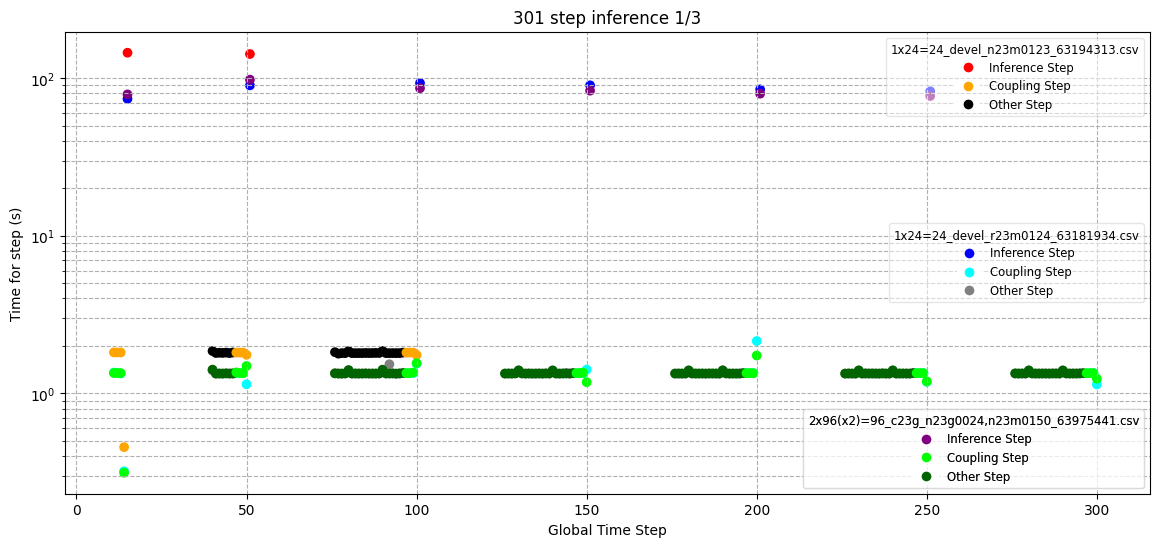

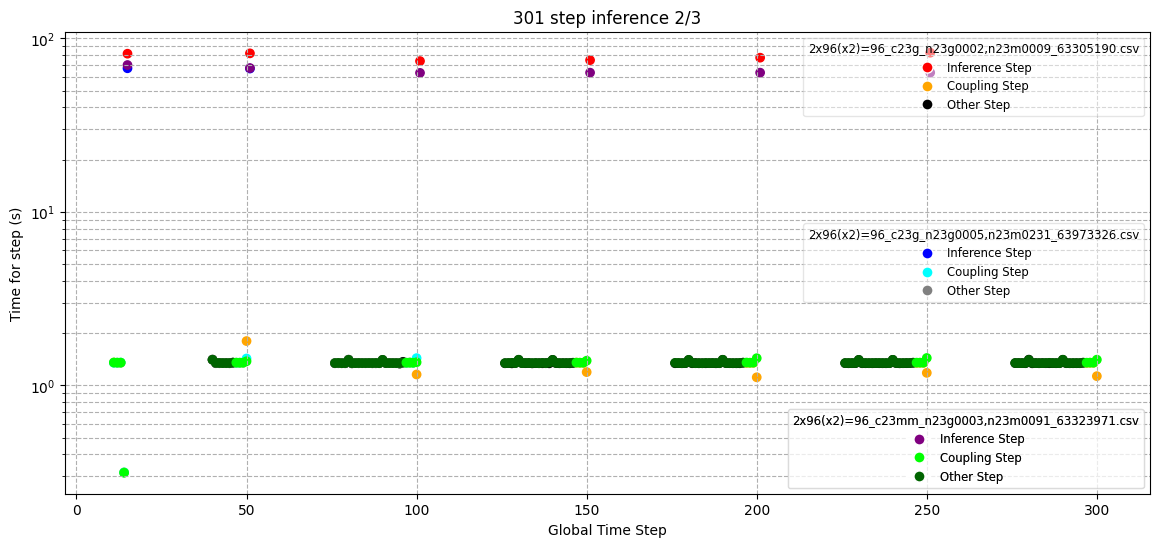

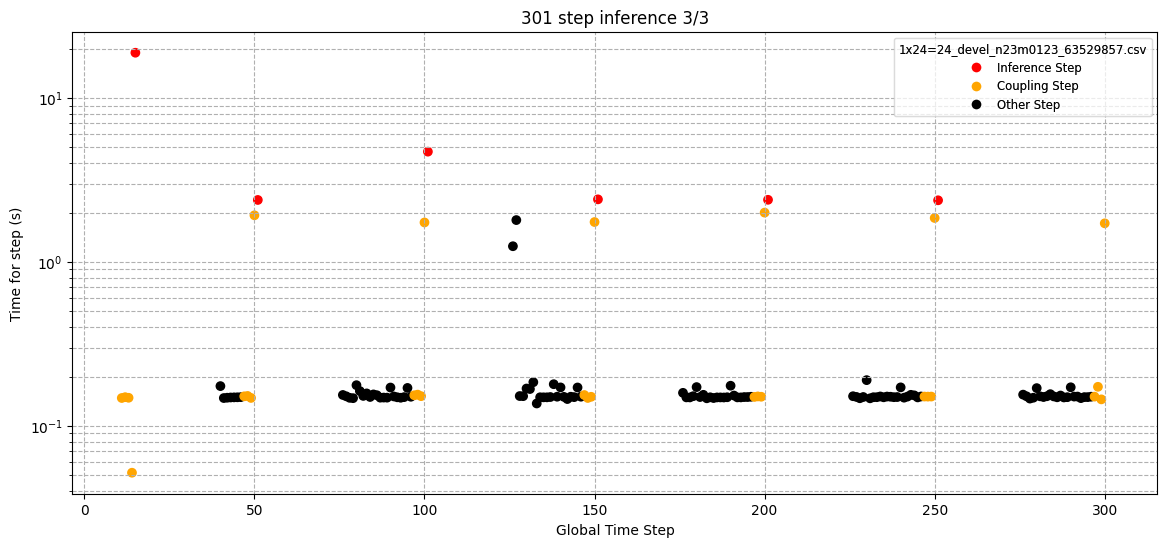

In [7]:

colorschemes = [['red', 'orange', 'black'], ['blue', 'cyan', 'gray'], ['purple', 'lime', 'darkgreen']]

max_steps = 0

for i, df in enumerate(dfs):
    color_index = i % len(colorschemes)
    colors = df.apply(lambda row: colorschemes[color_index][0] if row['inference'] else (colorschemes[color_index][1] if row['coupling'] else colorschemes[color_index][2]), axis=1)
    
    # Explain the color schemes to represent different runs and show source path as legend title
    legend_locs = ['upper right', 'right', 'lower right']
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label='Inference Step', markerfacecolor=colorschemes[color_index][0], markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Coupling Step',   markerfacecolor=colorschemes[color_index][1], markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Other Step',      markerfacecolor=colorschemes[color_index][2], markersize=8)
    ]
    # use the file path as the legend title to indicate source of the points
    plt.gca().add_artist(plt.legend(handles=legend_handles, loc=legend_locs[color_index],
                                    title=os.path.basename(paths[i]),
                                    title_fontsize='small',
                                    framealpha=0.5,
                                    fontsize='small'
                                    ))
    
    max_steps = max(max_steps, df['global_time_step'].max())
    
    plt.scatter(df['global_time_step'], df['time_diff'], c=colors)
    if i % 3 == 2 or i == len(dfs) - 1:
        plt.xlabel('Global Time Step')
        plt.ylabel('Time for step (s)')
        plt.yscale('log')
        plt.grid(True, which="both", ls="--")
        # specify the format of the plot
        plt.gcf().set_size_inches(14, 6)
        plt.title(max_steps.__str__() + ' step inference ' + (i // 3 + 1).__str__() + "/" + ((len(dfs) - 1) // 3 + 1).__str__())
        plt.show()
        max_steps = 0

[0.0, 1.817536587, 1.815748281, 1.816339411, 0.45543319, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 6.044250698208334, 1.855033417, 1.80234291, 1.807623656, 1.804144552, 1.811852301, 1.799856917, 1.814495213, 1.81269672, 1.813279555, 1.812605778, 1.754427921, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309748928333335, 5.9309

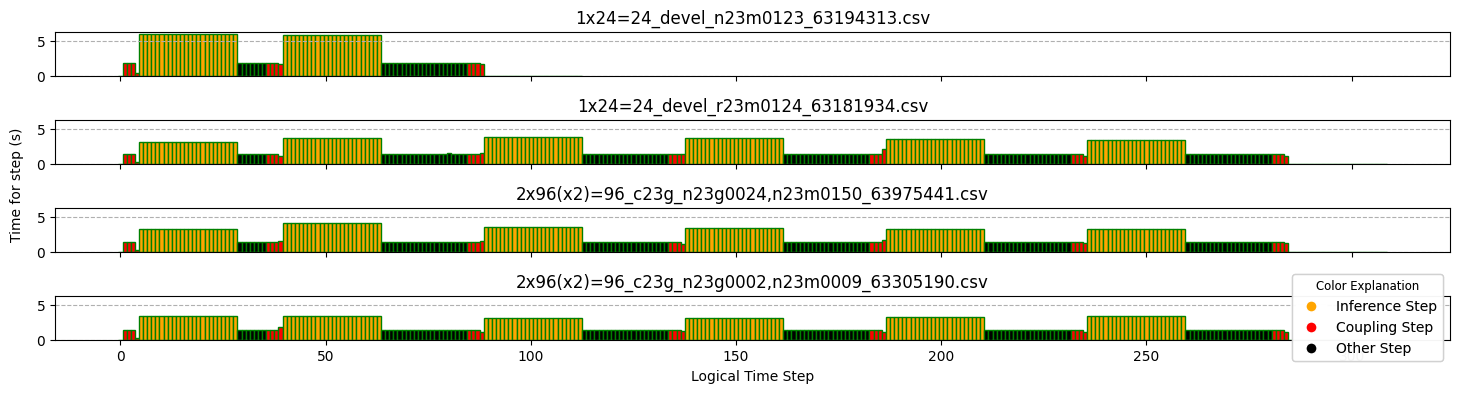

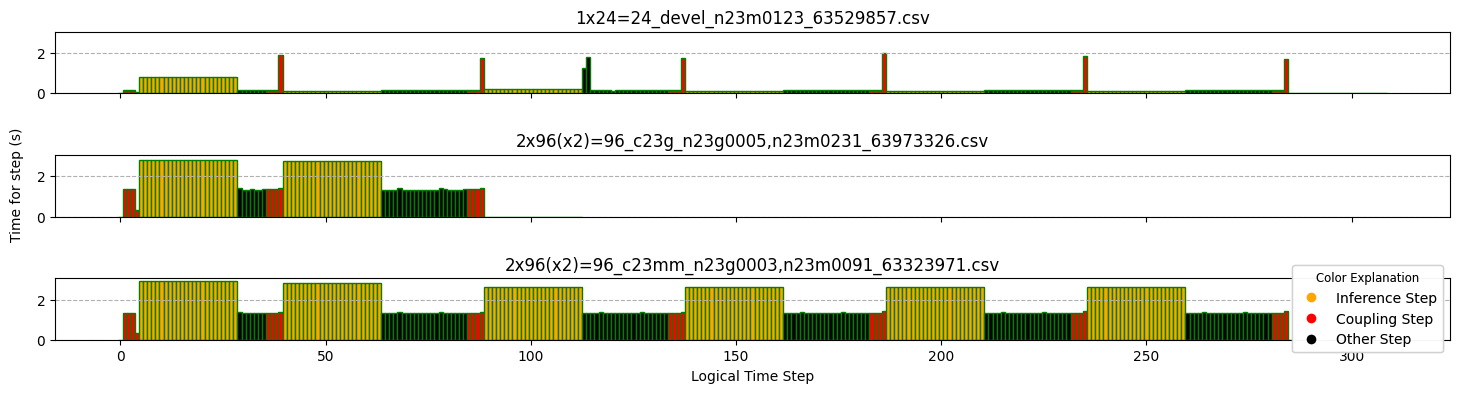

In [8]:
filled = []
filled_colors = []

for df in dfs:
    # get the max logical time step
    max_logical_time_step = int(df['logical_time_step'].max())
    times = []
    filled_color = []
    # We want to split the times of inference steps onto the next 24 steps equally
    i = 0
    while i <= max_logical_time_step:
        row = df[df['logical_time_step'] == i]
        if not row.empty:
            time = row['time_diff'].values[0]
            if row['inference'].values[0]:
                # split time onto next 24 steps
                split_time = time / 24.0
                for j in range(24):
                    times.append(split_time)
                    filled_color.append(1) # inference color
                i += 24
            elif row['coupling'].values[0]:
                times.append(time)
                filled_color.append(0) # coupling color
            else:
                times.append(time)
                filled_color.append(2) # other color
        else:
            times.append(0.0)
            filled_color.append(2) # other color
        i += 1
    filled.append(times)
    filled_colors.append(filled_color)
    
    print(list(map(lambda x: float(x), times)))
    print(filled_color)
    
plot_group_size = 4

for k in range(0, len(filled), plot_group_size):    
    
    remaining_length = min(plot_group_size,len(filled)-k)
    # plot the filled times as a sub-bar plot each with height corresponding to time taken and color corresponding to step type
    fig, axes = plt.subplots(remaining_length, 1, figsize=(18, 4), sharex=True, sharey=True, gridspec_kw={'hspace': 1.0})

    #for i, times in enumerate(filled):
    for i in range(k, min(k + plot_group_size, len(filled))):
        times = filled[i]
        ax = axes[i%remaining_length] if remaining_length > 1 else axes
        color_index = i % len(colorschemes)
        colors = []
        df = dfs[i]
        max_logical_time_step = int(df['logical_time_step'].max())

        for j in range(len(times)):
            logical_step = j // 24 if j < (max_logical_time_step + 1) * 24 else max_logical_time_step
            colors.append(colorschemes[0][filled_colors[i][j]])

        x = np.arange(len(times))
        ax.set_title(os.path.basename(paths[i]))
        ax.bar(x, times, color=colors, align='center', width=1.0, edgecolor='green')
        ax.grid(True, which="both", axis='y', ls="--")
        
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label='Inference Step', markerfacecolor=colorschemes[0][1], markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Coupling Step',   markerfacecolor=colorschemes[0][0], markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Other Step',      markerfacecolor=colorschemes[0][2], markersize=8)
    ]
    # use the file path as the legend title to indicate source of the points
    plt.gca().add_artist(plt.legend(handles=legend_handles, loc='right', title='Color Explanation', title_fontsize='small'))

    plt.xlabel('Logical Time Step')


    fig.text(0.10, 0.5, 'Time for step (s)', va='center', rotation='vertical')
    
    plt.show()
    